<a href="https://colab.research.google.com/drive/1cAsU9xaw_TBskOFfI4cygykWjgVg1cjN" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Week 2 - BRImo
### Nabila Shinta Luthfia
### 5026231038

In [12]:
#Install library yang digunakan untuk scraping Google Play Store
!pip install google_play_scraper
!pip install textblob

#Import library yang digunakan
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('seaborn-v0_8')
plt.rcParams["figure.figsize"] = (15,10)

In [ ]:
# Mengambil data review terbaru dari aplikasi BRImo di Google Play Store
# Menggunakan library google_play_scraper

from google_play_scraper import app, Sort, reviews_all

brimo_reviews = reviews_all(
    'id.co.bri.brimo',
    sleep_milliseconds=0,
    lang='id', # mengambil review bahasa Indonesia
    sort=Sort.NEWEST, # mengambil review terbaru
)

In [ ]:
# Data hasil scraping diubah menjadi pandas dataframe. Kemudian disimpan dalam file CSV untuk analisis selanjutnya
df_brimo = pd.DataFrame(np.array(brimo_reviews),columns=['content'])
df_brimo = df_brimo.join(pd.DataFrame(df_brimo.pop('content').tolist()))
df_brimo.to_csv("brimo_raw_reviews.csv", index=False) # menyimpan raw dataset
df_brimo.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,69f29837-ef0f-4ff8-bfa3-990179e35552,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantab dan cepat,5,0,None,2026-03-16 02:28:53,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-16 02:40:52,None
1,284b1e08-aab1-4302-a907-f6e1cb281a82,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,lebih mudah nyaman transaksi,5,0,2.95.0,2026-03-16 02:27:37,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-16 02:43:35,2.95.0
2,7c5b811e-d163-413a-8e7c-52493eca68d8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus,5,0,2.94.0,2026-03-16 02:19:08,"Hai Sobat BRI, terima kasih atas ulasannya 😊. ...",2026-03-16 02:41:24,2.94.0
3,88f8abeb-2efd-41c9-b393-29d37d776748,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat puas,5,0,2.95.0,2026-03-16 02:14:08,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-16 02:42:49,2.95.0
4,10cb1623-3478-4d06-a88a-47a180be3e9a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat mudah dan sangat membantu,5,0,None,2026-03-16 02:06:05,"Hai Sobat BRI, terima kasih atas ulasannya 😊. ...",2026-03-16 02:42:31,None


In [ ]:
import re
import string

def clean_text(text):

    text = str(text)
    text = text.lower()                     # mengubah semua huruf menjadi lowercase
    text = re.sub(r'http\S+', '', text)     # menghapus URL
    text = re.sub(r'\d+', '', text)         # menghapus angka
    text = re.sub(r'[^\w\s]', '', text)     # menghapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip()# menghapus spasi berlebih

    return text

In [ ]:
# Membuat kolom baru berisi review yang sudah dibersihkan
df_brimo['clean_review'] = df_brimo['content'].apply(clean_text)
df_brimo[['content','clean_review']].head()

,content,clean_review
0,mantab dan cepat,mantab dan cepat
1,lebih mudah nyaman transaksi,lebih mudah nyaman transaksi
2,bagus,bagus
3,sangat puas,sangat puas
4,sangat mudah dan sangat membantu,sangat mudah dan sangat membantu


In [ ]:
df_brimo = pd.DataFrame(np.array(brimo_reviews), columns=['review'])
df_brimo = df_brimo.join(pd.DataFrame(df_brimo.pop('review').tolist()))

In [ ]:
print(df_brimo.columns)

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='object')


In [ ]:
print(df_brimo['reviewCreatedVersion'].unique())
print(df_brimo['reviewCreatedVersion'].nunique())

[None '2.95.0' '2.94.0' '2.93.0' '2.92.0' '2.92.1' '2.70.0' '2.38.0'
 '2.88.0' '2.87.1' '2.85.0' '2.83.0' '2.91.0' '2.89.0' '2.63.0' '2.71.1'
 '2.90.0' '2.35.0' '2.62.0' '2.23.0' '1.8.0' '2.76.0' '2.88.1' '2.8.0'
 '2.78.0' '2.86.0' '2.80.0' '2.30.0' '2.44.0' '2.56.0' '2.20.1' '2.52.0'
 '2.58.0' '2.72.0' '2.40.0' '2.79.0' '2.84.0' '2.75.0' '2.57.0' '2.45.1'
 '2.32.0' '2.27.0' '2.20.0' '2.53.0' '2.22.0' '2.59.0' '2.61.0' '2.74.0'
 '2.82.0' '2.46.0' '2.42.0' '2.34.0' '2.48.0' '2.81.0' '2.29.0' '2.11.0'
 '2.23.1' '2.26.0' '1.4.1' '2.21.0' '2.39.0' '2.77.0' '2.64.0' '1.7.0'
 '2.77.1' '2.18.0' '2.31.0' '2.49.0' '2.51.0' '2.43.1' '2.7.0' '2.69.0'
 '2.25.0' '2.55.0' '2.68.0' '2.37.0' '2.47.0' '2.14.0' '2.60.0' '2.57.1'
 '2.1.0' '2.13.0' '2.65.0' '2.67.0' '2.41.0' '2.3.2' '2.71.0' '2.73.0'
 '2.43.0' '2.17.0' '2.67.1' '2.3.0' '2.66.0' '2.24.0' '2.2.0' '2.10.0'
 '2.54.0' '2.33.0' '2.12.0' '1.5.0' '2.36.0' '2.15.0' '2.50.0' '2.3.1'
 '2.16.0' '2.87.0' '2.28.0' '2.6.0' '1.3.3' '1.4.2' '1.6.3' '2.45.

In [ ]:
# Menyimpan dataset setelah proses cleaning
df_brimo.to_csv("brimo_clean_reviews.csv", index=False)

In [ ]:
# Menampilkan kolom yang relevan untuk analisis review aplikasi
df_brimo.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,mantab dan cepat,5,0,None,2026-03-16 02:28:53,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-16 02:40:52
1,lebih mudah nyaman transaksi,5,0,2.95.0,2026-03-16 02:27:37,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-16 02:43:35
2,bagus,5,0,2.94.0,2026-03-16 02:19:08,"Hai Sobat BRI, terima kasih atas ulasannya 😊. ...",2026-03-16 02:41:24
3,sangat puas,5,0,2.95.0,2026-03-16 02:14:08,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-16 02:42:49
4,sangat mudah dan sangat membantu,5,0,None,2026-03-16 02:06:05,"Hai Sobat BRI, terima kasih atas ulasannya 😊. ...",2026-03-16 02:42:31
...,...,...,...,...,...,...,...
859080,jozz,5,1,1.3.0,2019-02-26 05:49:31,None,NaT
859081,semakin canggih aplikasi BRI dan dipermudah lagi,5,2,None,2019-02-26 05:43:51,None,NaT
859082,mantapsss,5,0,1.3.0,2019-02-26 05:38:54,None,NaT
859083,gooooooood,5,1,1.3.0,2019-02-26 05:31:38,None,NaT


In [ ]:
# Library emoji digunakan untuk memproses karakter emoji dalam teks review
!pip install emoji

# Library tambahan untuk text preprocessing dan Natural Language Processing (NLP)
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#from pandas_profiling import ProfileReport
import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 16.3 MB/s eta 0:00:00


In [13]:
# Menghitung nilai sentiment dari setiap review menggunakan TextBlob
# Polarity menunjukkan tingkat positif/negatif
# Subjectivity menunjukkan tingkat subjektif atau objektif
# https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
df_brimo['sentiment_polarity'] = df_brimo['content'].apply(lambda x: TextBlob(str(x)).polarity)
df_brimo['sentiment_subjective'] = df_brimo['content'].apply(lambda x: TextBlob(str(x)).subjectivity)

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
# Menyimpan dataset setelah sentiment analysis
df_brimo.to_csv("brimo_sentiment_reviews.csv", index=False)

In [17]:
# Menampilkan isi review beserta nilai sentiment yang dihasilkan
df_brimo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,mantab dan cepat,5,0.0,0.0
1,lebih mudah nyaman transaksi,5,0.0,0.0
2,bagus,5,0.0,0.0
3,sangat puas,5,0.0,0.0
4,sangat mudah dan sangat membantu,5,0.0,0.0
...,...,...,...,...
859080,jozz,5,0.0,0.0
859081,semakin canggih aplikasi BRI dan dipermudah lagi,5,0.0,0.0
859082,mantapsss,5,0.0,0.0
859083,gooooooood,5,0.0,0.0


In [18]:
# Menghitung jumlah review berdasarkan rating yang diberikan pengguna
df_brimo['score'].value_counts()

,count
score,
5,614508
1,135500
4,51449
2,28945
3,28683


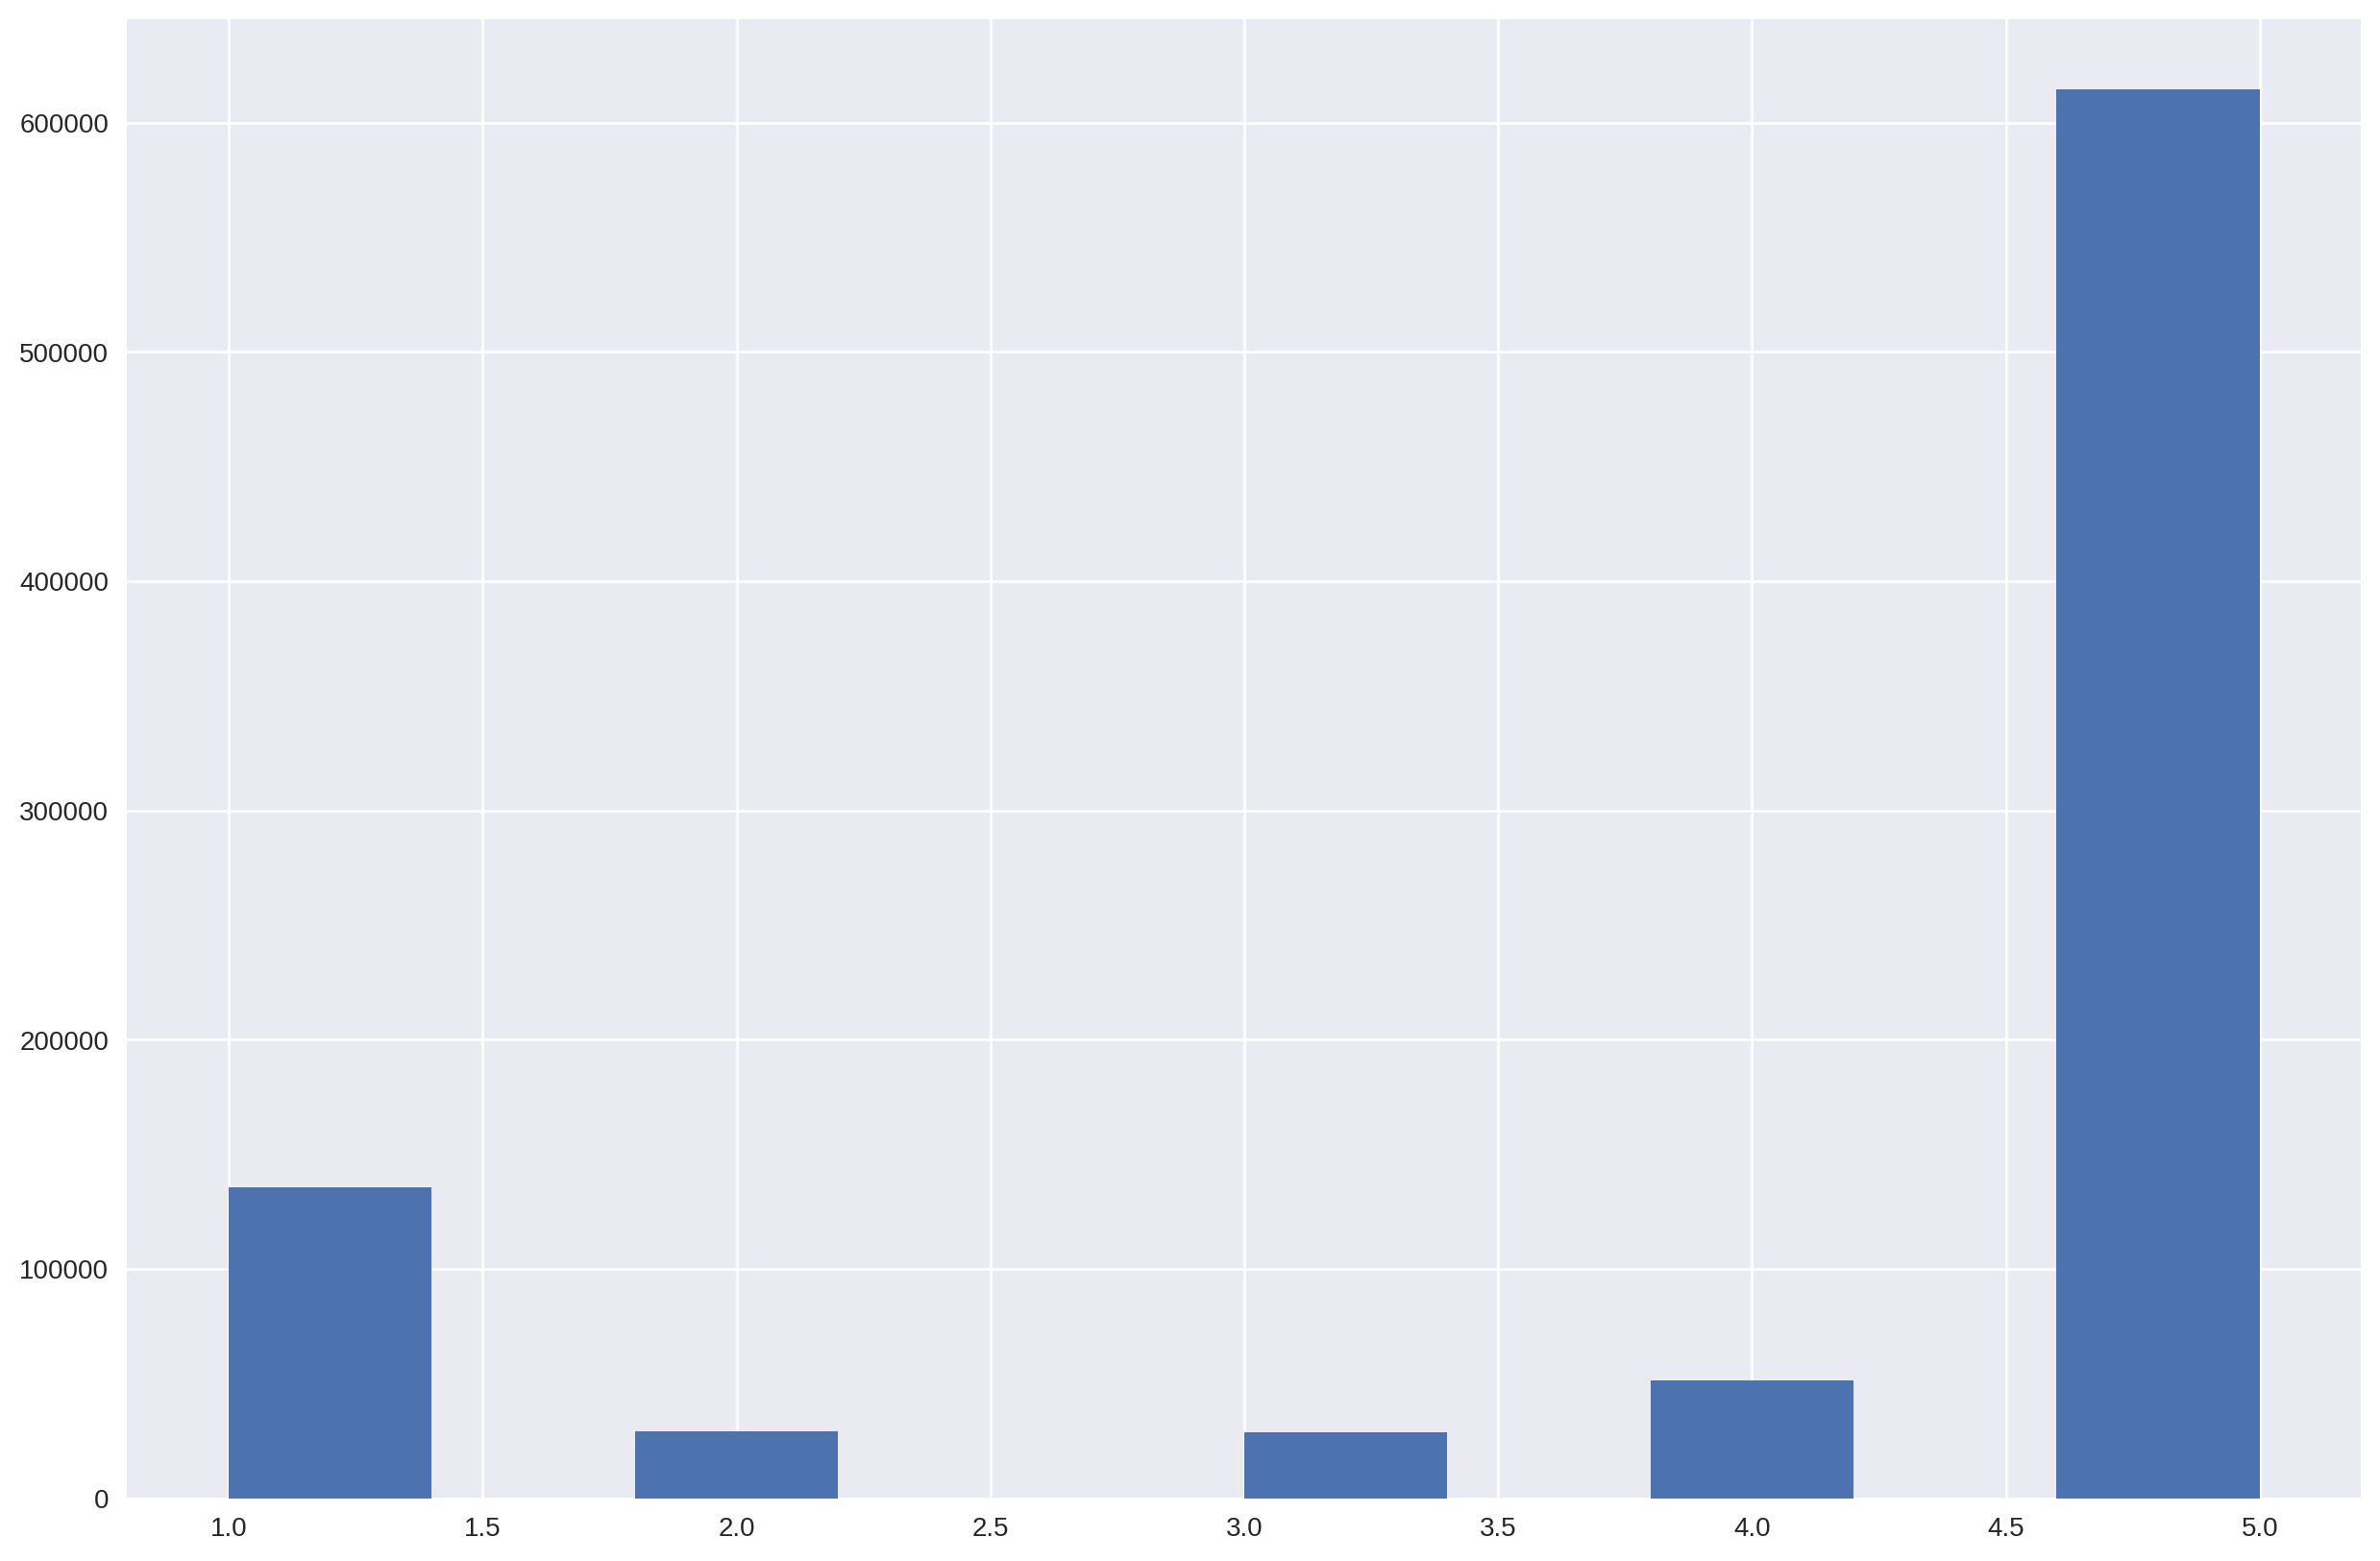

In [19]:
# Membuat grafik distribusi rating pengguna terhadap aplikasi BRImo
plt.hist(df_brimo['score'])
plt.show()